# Telemetry Branch — XGBoost Multiclass Baseline

**In-Cabin Multi-Modal Driver Risk Assessment · FYP2 model training**

This notebook trains the **telemetry** evidence branch: a multiclass XGBoost classifier over
**Safe / Aggressive / Distracted** driving behaviour, using the 8 leakage-audited telemetry features.

**Contract note.** The fusion layer consumes `P_telemetry_anomaly = 1 − P(Safe)` — i.e. the
*non-safe behaviour probability*. This is **not** an anomaly-detection model; it is the complement
of the Safe-class probability from this 3-class classifier.

**Data.** EDA-cleaned, driver-agnostic stratified splits prepared upstream
(`eda_outputs/processed/telemetry/telemetry_{train,val,test}.csv`).

> ⚠️ **Honest-reporting caveat (read before quoting numbers).** `Driver_Behavior.csv` is a
> **synthetic / rule-generated** dataset whose classes are near-separable. Expect near-perfect
> metrics — these demonstrate the *pipeline*, not real-world telemetry difficulty. Disclose this
> in the report/viva; do not present it as evidence of field accuracy.

In [1]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import (accuracy_score, f1_score, log_loss, roc_auc_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
import xgboost
print('xgboost', xgboost.__version__)

xgboost 3.2.0


## 1 · Resolve paths & label contract

In [2]:
import os
from pathlib import Path

# --- Dataset location (override with env FYP_DATA_ROOT) ----------------------
# The EDA-prepared splits + images live in the *sibling* repo
# "FYP-In-Cabin-Driver-Assessment-" (note: no trailing 1). Nothing is copied;
# we read straight from there.
DATA_ROOT = Path(os.environ.get(
    "FYP_DATA_ROOT", str(Path.home() / "Desktop" / "FYP-In-Cabin-Driver-Assessment-")
)).expanduser()
assert DATA_ROOT.exists(), (
    f"Dataset root not found: {DATA_ROOT}\n"
    f"Set env FYP_DATA_ROOT to the repo that holds eda_outputs/."
)

# Outputs land under ml/outputs/ in THIS repo, regardless of where Jupyter was
# launched (kernel cwd may be the branch folder OR the repo root).
def _find_ml_outputs():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if p.name == "ml":
            return p / "outputs"
        if (p / "ml" / "telemetry").exists():
            return p / "ml" / "outputs"
    return here / "outputs"

OUT = _find_ml_outputs()
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUTS  :", OUT)

TEL = DATA_ROOT / "eda_outputs" / "processed" / "telemetry"
TEL_OUT = OUT / "telemetry"; TEL_OUT.mkdir(parents=True, exist_ok=True)

# Canonical label order: index 0 == Safe so P_telemetry_anomaly = 1 - P(Safe).
LABELS = ["Safe", "Aggressive", "Distracted"]
FEATURES = pd.read_csv(TEL / "telemetry_feature_order.csv")["feature"].tolist()
print(f"{len(FEATURES)} features:", FEATURES)

DATA_ROOT: /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment-
OUTPUTS  : /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment--1/ml/outputs
8 features: ['speed_kmph', 'accel_x', 'accel_y', 'brake_pressure', 'steering_angle', 'throttle', 'lane_deviation', 'headway_distance']


## 2 · Load prepared splits

In [3]:
def load_split(name):
    df = pd.read_csv(TEL / f"telemetry_{name}.csv")
    y = df["behavior_label"].map({n: i for i, n in enumerate(LABELS)}).to_numpy(int)
    X = df[FEATURES].astype(float)
    return X, y

X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")
print("sizes  train/val/test:", len(y_train), len(y_val), len(y_test))
pd.Series(y_train).value_counts().rename(index=dict(enumerate(LABELS))).to_frame("train_count")

sizes  train/val/test: 21000 4500 4500


,train_count
Safe,7000
Aggressive,7000
Distracted,7000


## 3 · Train XGBoost (early stopping on validation)

In [4]:
clf = XGBClassifier(
    objective="multi:softprob", num_class=len(LABELS),
    n_estimators=400, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric="mlogloss", early_stopping_rounds=30,
    tree_method="hist", random_state=42, n_jobs=-1,
)
t0 = time.time()
clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"trained in {time.time()-t0:.2f}s  best_iteration={clf.best_iteration}")

trained in 0.67s  best_iteration=90


## 4 · Evaluate (val + test)

In [5]:
def evaluate(split, X, y):
    proba = clf.predict_proba(X); pred = proba.argmax(1)
    rep = classification_report(y, pred, target_names=LABELS, output_dict=True, zero_division=0)
    m = {
        "accuracy": float(accuracy_score(y, pred)),
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "weighted_f1": float(f1_score(y, pred, average="weighted")),
        "log_loss": float(log_loss(y, proba, labels=list(range(len(LABELS))))),
        "macro_auc_ovr": float(roc_auc_score(y, proba, multi_class="ovr", average="macro")),
        "per_class": {n: {"precision": rep[n]["precision"], "recall": rep[n]["recall"],
                          "f1": rep[n]["f1-score"], "support": rep[n]["support"]} for n in LABELS},
        "confusion_matrix": confusion_matrix(y, pred).tolist(),
    }
    print(f"{split:>5}: acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}  "
          f"logloss={m['log_loss']:.4f}  macroAUC={m['macro_auc_ovr']:.4f}")
    return m

results = {"val": evaluate("val", X_val, y_val), "test": evaluate("test", X_test, y_test)}
print("\n=== TEST classification report ===")
print(classification_report(y_test, clf.predict(X_test), target_names=LABELS, digits=4, zero_division=0))

  val: acc=0.9984  macroF1=0.9984  logloss=0.0048  macroAUC=1.0000
 test: acc=0.9993  macroF1=0.9993  logloss=0.0037  macroAUC=1.0000

=== TEST classification report ===
              precision    recall  f1-score   support

        Safe     0.9993    1.0000    0.9997      1500
  Aggressive     0.9987    1.0000    0.9993      1500
  Distracted     1.0000    0.9980    0.9990      1500

    accuracy                         0.9993      4500
   macro avg     0.9993    0.9993    0.9993      4500
weighted avg     0.9993    0.9993    0.9993      4500



## 5 · Confusion matrix & feature importance

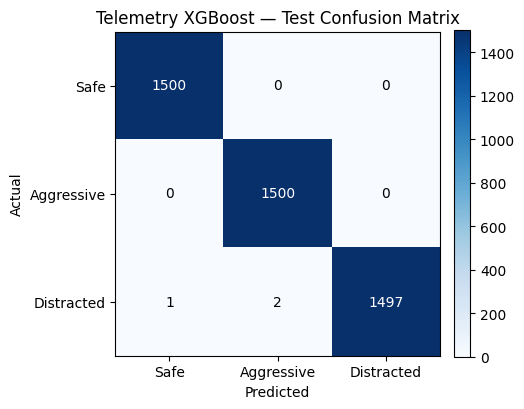

In [6]:
cm = np.array(results["test"]["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABELS)), LABELS); ax.set_yticks(range(len(LABELS)), LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Telemetry XGBoost — Test Confusion Matrix")
th = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > th else "black")
fig.colorbar(im, fraction=0.046, pad=0.04); fig.tight_layout()
fig.savefig(TEL_OUT / "confusion_matrix_test.png", dpi=150); plt.show()

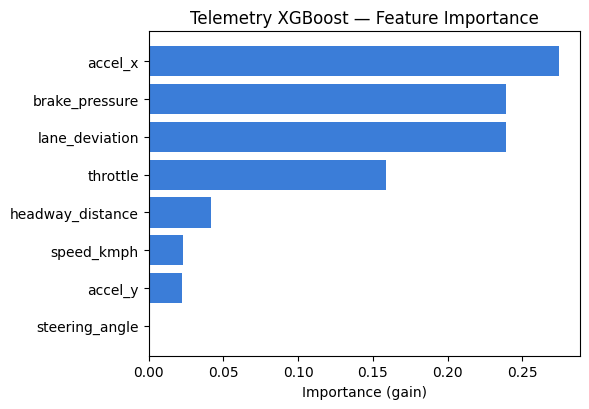

[('accel_x', 0.27472785115242004),
 ('brake_pressure', 0.23925398290157318),
 ('lane_deviation', 0.2391422837972641),
 ('throttle', 0.15869881212711334),
 ('headway_distance', 0.041432201862335205),
 ('speed_kmph', 0.02330506592988968),
 ('accel_y', 0.022344721481204033),
 ('steering_angle', 0.0010951247531920671)]

In [7]:
fi = sorted(zip(FEATURES, (float(v) for v in clf.feature_importances_)),
            key=lambda kv: kv[1], reverse=True)
feats = [f for f, _ in fi][::-1]; vals = [v for _, v in fi][::-1]
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.barh(feats, vals, color="#3b7dd8"); ax.set_xlabel("Importance (gain)")
ax.set_title("Telemetry XGBoost — Feature Importance"); fig.tight_layout()
fig.savefig(TEL_OUT / "feature_importance.png", dpi=150); plt.show()
fi

## 6 · Persist artifacts

In [8]:
clf.get_booster().save_model(str(TEL_OUT / "xgb_telemetry.json"))
summary = {
    "model": "XGBoost multi:softprob", "branch": "telemetry", "classes": LABELS,
    "n_features": len(FEATURES), "features": FEATURES,
    "split_sizes": {"train": int(len(y_train)), "val": int(len(y_val)), "test": int(len(y_test))},
    "best_iteration": int(clf.best_iteration), "metrics": results,
    "feature_importance_gain": [{"feature": f, "importance": v} for f, v in fi],
    "data_root": str(DATA_ROOT), "xgboost_version": xgboost.__version__,
    "caveat": "Driver_Behavior.csv is synthetic/near-separable; metrics show the pipeline, not field accuracy.",
}
(TEL_OUT / "metrics.json").write_text(json.dumps(summary, indent=2))
(TEL_OUT / "classification_report_test.txt").write_text(
    classification_report(y_test, clf.predict(X_test), target_names=LABELS, digits=4, zero_division=0))
print("saved ->", TEL_OUT)
print(f"TEST baseline: acc={results['test']['accuracy']:.4f}  macroF1={results['test']['macro_f1']:.4f}")

saved -> /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment--1/ml/outputs/telemetry
TEST baseline: acc=0.9993  macroF1=0.9993


## 7 · Final summary (report-ready)

In [9]:
# Reads the metrics it just wrote, so this cell is a stable, copy-paste-ready
# block for the report (re-runnable on its own once metrics.json exists).
import json, pandas as pd
S = json.loads((TEL_OUT / "metrics.json").read_text())
t, v = S["metrics"]["test"], S["metrics"]["val"]
print("=" * 64)
print(f"TELEMETRY BRANCH — {S['model']}  ({S['n_features']} features)")
print("=" * 64)
print(f"Split   : train/val/test = {S['split_sizes']['train']}/"
      f"{S['split_sizes']['val']}/{S['split_sizes']['test']}")
print(f"Val     : accuracy={v['accuracy']:.4f}  macro-F1={v['macro_f1']:.4f}")
print(f"Test    : accuracy={t['accuracy']:.4f}  macro-F1={t['macro_f1']:.4f}  "
      f"weighted-F1={t['weighted_f1']:.4f}  logloss={t['log_loss']:.4f}  "
      f"macro-AUC={t['macro_auc_ovr']:.4f}")
print()
pc = pd.DataFrame(t["per_class"]).T[["precision", "recall", "f1", "support"]].round(4)
print("Per-class (test):"); print(pc.to_string())
print()
print("Top features (gain): " +
      ", ".join(f"{d['feature']}={d['importance']:.3f}" for d in S["feature_importance_gain"][:4]))
print(f"Artifacts: {TEL_OUT}")
print("CAVEAT  :", S["caveat"])

TELEMETRY BRANCH — XGBoost multi:softprob  (8 features)
Split   : train/val/test = 21000/4500/4500
Val     : accuracy=0.9984  macro-F1=0.9984
Test    : accuracy=0.9993  macro-F1=0.9993  weighted-F1=0.9993  logloss=0.0037  macro-AUC=1.0000

Per-class (test):
            precision  recall      f1  support
Safe           0.9993   1.000  0.9997   1500.0
Aggressive     0.9987   1.000  0.9993   1500.0
Distracted     1.0000   0.998  0.9990   1500.0

Top features (gain): accel_x=0.275, brake_pressure=0.239, lane_deviation=0.239, throttle=0.159
Artifacts: /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment--1/ml/outputs/telemetry
CAVEAT  : Driver_Behavior.csv is synthetic/near-separable; metrics show the pipeline, not field accuracy.
